# XGBoost xG Model

Trains and evaluates an XGBoost expected-goals classifier on StatsBomb open data.

**Pipeline summary:**
1. Load data and engineer features (reuses `src.features`)
2. Preprocess — encode categoricals, impute freeze-frame missingness
3. Tune hyperparameters with Optuna (stratified 5-fold CV, log-loss objective)
4. Final cross-validated evaluation — AUC, log-loss, Brier score
5. Calibration curve
6. SHAP feature importance
7. Save model to `outputs/`

In [1]:
%load_ext autoreload
%autoreload 2

import sys, warnings, os
warnings.filterwarnings('ignore')
sys.path.insert(0, '..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import xgboost as xgb
import shap
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.metrics import (
    roc_auc_score, log_loss, brier_score_loss,
    RocCurveDisplay, PrecisionRecallDisplay,
)
from sklearn.calibration import calibration_curve
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from statsbombpy import sb

from src.features import create_xg_features

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.dpi'] = 120
os.makedirs('../outputs', exist_ok=True)

## 1. Data Loading and Feature Engineering

In [2]:
COMPETITIONS = [
    #{'competition_id': 11, 'season_id': 27,  'label': 'La Liga 2015/16'},
    {'competition_id': 16, 'season_id': 4,   'label': 'Champions League 2018/19'},
    #{'competition_id': 2,  'season_id': 27,  'label': 'Premier League 2015/16'},
    {'competition_id': 43, 'season_id': 106, 'label': 'World Cup 2022'},
]

def load_competition(competition_id, season_id):
    matches = sb.matches(competition_id=competition_id, season_id=season_id)
    return pd.concat(
        [sb.events(match_id=mid).assign(match_id=mid) for mid in matches['match_id']],
        ignore_index=True,
    )

all_events = []
for comp in COMPETITIONS:
    print(f"Loading {comp['label']}…")
    all_events.append(load_competition(comp['competition_id'], comp['season_id']))

events_df = pd.concat(all_events, ignore_index=True)
xg_df = create_xg_features(events_df)

# Penalties are excluded — their fixed location and high base rate warrant a separate model.
shots = xg_df[xg_df['is_penalty'] == 0].copy().reset_index(drop=True)

print(f"\nShots (excl. penalties): {len(shots):,}")
print(f"Goals: {shots['is_goal'].sum():,} ({shots['is_goal'].mean():.1%})")

Loading Champions League 2018/19…
Loading World Cup 2022…

Shots (excl. penalties): 1,459
Goals: 153 (10.5%)


## 2. Preprocessing

In [3]:
CATEGORICAL_FEATURES = ['shot_body_part', 'shot_technique', 'previous_event_type']

NUMERIC_FEATURES = [
    'distance_to_goal', 'shot_angle', 'centrality',
    'in_penalty_area', 'in_six_yard_box',
    'shot_first_time', 'shot_under_pressure',
    'num_defenders_in_frame', 'num_teammates_in_frame',
    'distance_to_nearest_defender', 'num_defenders_between_shot_and_goal',
    'goalkeeper_distance_to_goal', 'goalkeeper_distance_to_shooter',
    'previous_event_was_pass', 'previous_event_was_carry',
    'previous_event_same_team', 'previous_event_distance',
    'is_late_game', 'is_extra_time',
]

TARGET = 'is_goal'

preprocessor = ColumnTransformer([
    # Freeze-frame features have ~40% missingness; median imputation is deliberate
    # since their distribution is skewed (most shots have 0 defenders in lane).
    ('num', SimpleImputer(strategy='median'), NUMERIC_FEATURES),
    ('cat', Pipeline([
        ('impute', SimpleImputer(strategy='constant', fill_value='Unknown')),
        ('ohe', OneHotEncoder(handle_unknown='ignore', sparse_output=False)),
    ]), CATEGORICAL_FEATURES),
], remainder='drop')

X = shots[NUMERIC_FEATURES + CATEGORICAL_FEATURES]
y = shots[TARGET].values

# Dry run to confirm preprocessing works and check output shape.
X_transformed = preprocessor.fit_transform(X)
print(f"Feature matrix shape: {X_transformed.shape}")

ohe_feature_names = (
    preprocessor.named_transformers_['cat']['ohe']
    .get_feature_names_out(CATEGORICAL_FEATURES)
    .tolist()
)
ALL_FEATURE_NAMES = NUMERIC_FEATURES + ohe_feature_names
print(f"Total features after encoding: {len(ALL_FEATURE_NAMES)}")

Feature matrix shape: (1459, 50)
Total features after encoding: 50


## 3. Hyperparameter Tuning (Optuna)

In [4]:
CV = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

def objective(trial):
    params = {
        'n_estimators':      trial.suggest_int('n_estimators', 200, 1000, step=100),
        'max_depth':         trial.suggest_int('max_depth', 3, 7),
        'learning_rate':     trial.suggest_float('learning_rate', 0.01, 0.2, log=True),
        'subsample':         trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree':  trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'min_child_weight':  trial.suggest_int('min_child_weight', 1, 10),
        'reg_alpha':         trial.suggest_float('reg_alpha', 1e-4, 10.0, log=True),
        'reg_lambda':        trial.suggest_float('reg_lambda', 1e-4, 10.0, log=True),
        'objective': 'binary:logistic',
        'eval_metric': 'logloss',
        'use_label_encoder': False,
        'random_state': 42,
        'n_jobs': -1,
    }
    model = Pipeline([
        ('pre', preprocessor),
        ('clf', xgb.XGBClassifier(**params)),
    ])
    fold_losses = []
    for train_idx, val_idx in CV.split(X, y):
        model.fit(X.iloc[train_idx], y[train_idx])
        proba = model.predict_proba(X.iloc[val_idx])[:, 1]
        fold_losses.append(log_loss(y[val_idx], proba))
    return np.mean(fold_losses)

study = optuna.create_study(direction='minimize', sampler=optuna.samplers.TPESampler(seed=42))
study.optimize(objective, n_trials=50, show_progress_bar=True)

print(f"\nBest log-loss: {study.best_value:.4f}")
print(f"Best params:")
for k, v in study.best_params.items():
    print(f"  {k}: {v}")

  0%|          | 0/50 [00:00<?, ?it/s]


Best log-loss: 0.2759
Best params:
  n_estimators: 300
  max_depth: 4
  learning_rate: 0.010153653342240814
  subsample: 0.8579178144028043
  colsample_bytree: 0.5258350549942348
  min_child_weight: 7
  reg_alpha: 0.00012148275333719446
  reg_lambda: 0.0001063211006951443


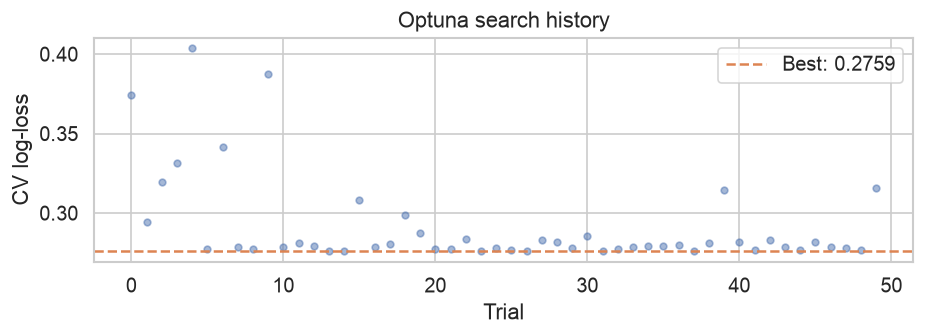

In [5]:
# Optuna optimisation history
fig, ax = plt.subplots(figsize=(8, 3))
trials_df = study.trials_dataframe()
ax.plot(trials_df['number'], trials_df['value'], 'o', alpha=0.5, ms=4, color='#4C72B0')
ax.axhline(study.best_value, color='#DD8452', linewidth=1.5, linestyle='--', label=f'Best: {study.best_value:.4f}')
ax.set_xlabel('Trial')
ax.set_ylabel('CV log-loss')
ax.set_title('Optuna search history')
ax.legend()
plt.tight_layout()
plt.show()

## 4. Final Cross-Validated Evaluation

In [6]:
best_params = {
    **study.best_params,
    'objective': 'binary:logistic',
    'eval_metric': 'logloss',
    'use_label_encoder': False,
    'random_state': 42,
    'n_jobs': -1,
}

final_model = Pipeline([
    ('pre', preprocessor),
    ('clf', xgb.XGBClassifier(**best_params)),
])

# cross_val_predict gives out-of-fold probabilities — each shot is predicted
# by a model that never saw it during training.
oof_proba = cross_val_predict(final_model, X, y, cv=CV, method='predict_proba')[:, 1]

metrics = {
    'ROC-AUC':    roc_auc_score(y, oof_proba),
    'Log-loss':   log_loss(y, oof_proba),
    'Brier score': brier_score_loss(y, oof_proba),
}

print("Out-of-fold evaluation metrics:")
for name, val in metrics.items():
    print(f"  {name:<15} {val:.4f}")

Out-of-fold evaluation metrics:
  ROC-AUC         0.7959
  Log-loss        0.2759
  Brier score     0.0796


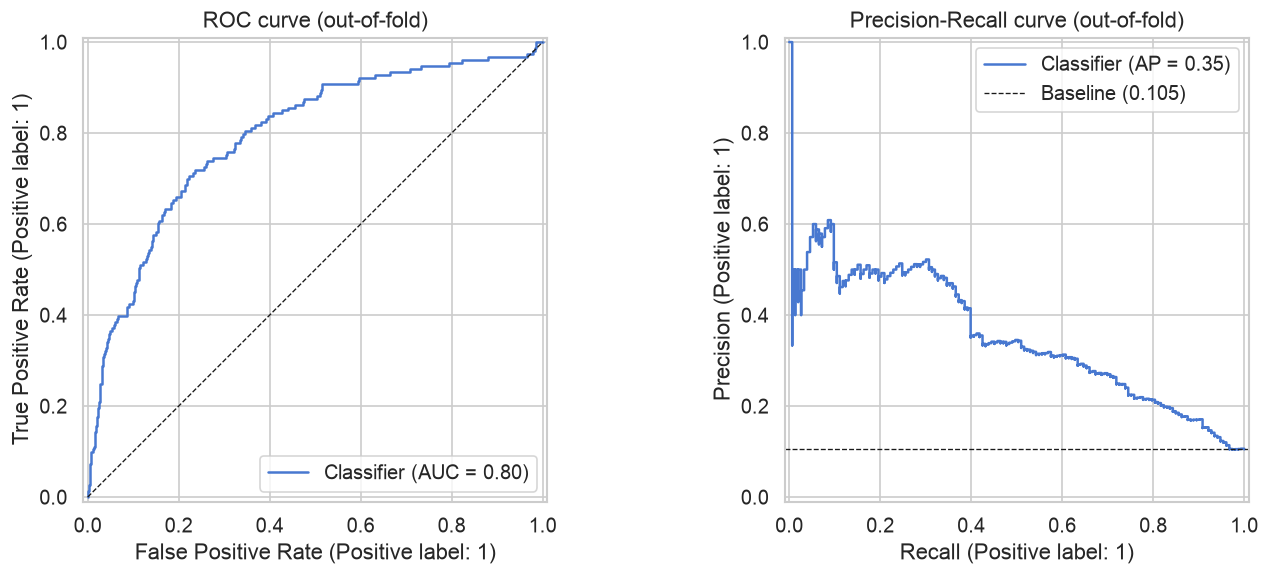

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

RocCurveDisplay.from_predictions(y, oof_proba, ax=axes[0])#, color="#4E77B8")
axes[0].plot([0, 1], [0, 1], 'k--', linewidth=0.8)
axes[0].set_title('ROC curve (out-of-fold)')

PrecisionRecallDisplay.from_predictions(y, oof_proba, ax=axes[1])#, color="#DA824E")
axes[1].axhline(y.mean(), color='k', linestyle='--', linewidth=0.8, label=f'Baseline ({y.mean():.3f})')
axes[1].legend()
axes[1].set_title('Precision-Recall curve (out-of-fold)')

plt.tight_layout()
plt.show()

## 5. Calibration

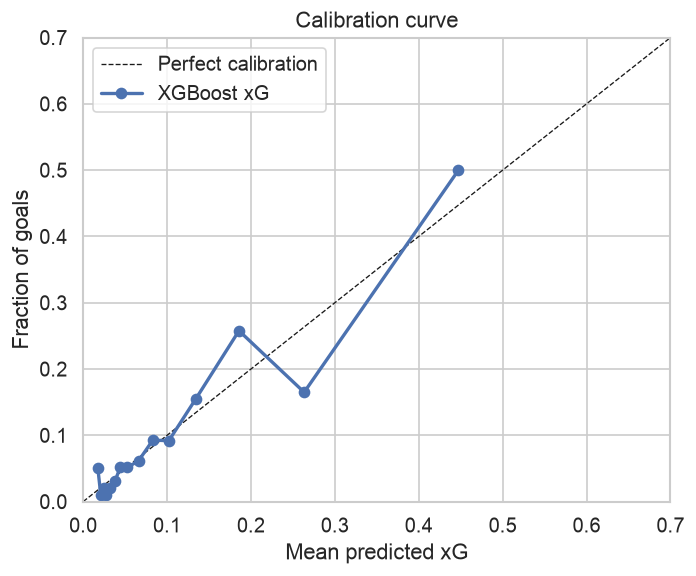

Expected Calibration Error (ECE): 0.0120


In [10]:
# Good calibration is the core requirement for xG: a shot assigned 0.3 xG should
# genuinely convert ~30% of the time.
fraction_pos, mean_pred = calibration_curve(y, oof_proba, n_bins=15, strategy='quantile')

fig, ax = plt.subplots(figsize=(6, 5))
ax.plot([0, 1], [0, 1], 'k--', linewidth=0.8, label='Perfect calibration')
ax.plot(mean_pred, fraction_pos, 'o-', color='#4C72B0', linewidth=2, markersize=6, label='XGBoost xG')
ax.set_xlabel('Mean predicted xG')
ax.set_ylabel('Fraction of goals')
ax.set_title('Calibration curve')
ax.legend()
ax.set_xlim(0, 0.7)
ax.set_ylim(0, 0.7)
plt.tight_layout()
plt.show()

# ECE — Expected Calibration Error (lower is better)
bins = np.linspace(0, 1, 11)
bin_ids = np.digitize(oof_proba, bins) - 1
ece = sum(
    (np.sum(bin_ids == b) / len(y)) * abs(y[bin_ids == b].mean() - oof_proba[bin_ids == b].mean())
    for b in range(len(bins) - 1) if np.sum(bin_ids == b) > 0
)
print(f"Expected Calibration Error (ECE): {ece:.4f}")

## 6. xG Distribution

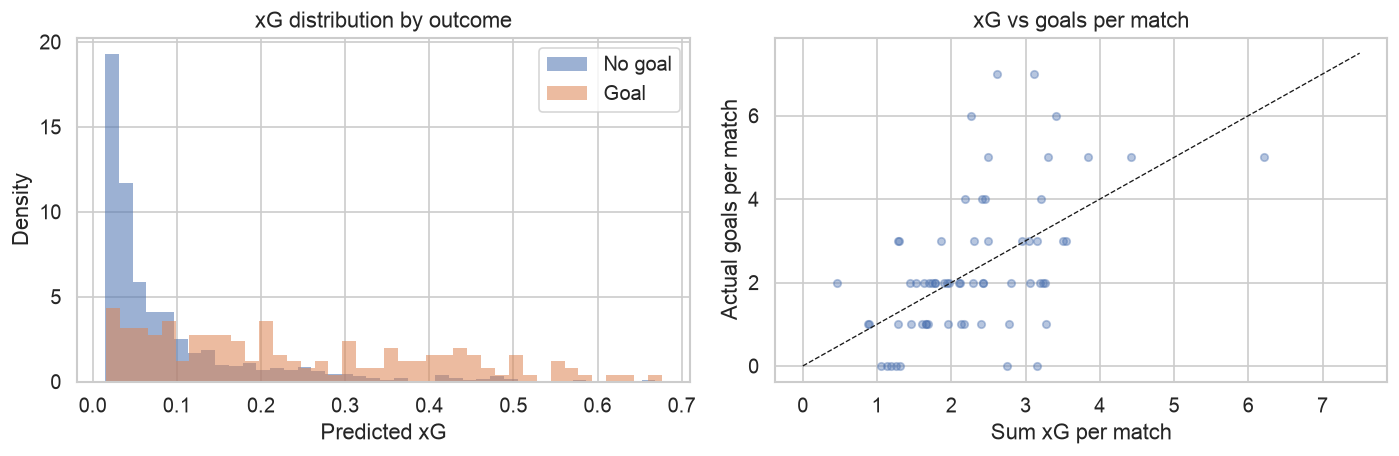

Match-level Pearson r (xG vs goals): 0.528


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for outcome, label, color in [(0, 'No goal', '#4C72B0'), (1, 'Goal', '#DD8452')]:
    axes[0].hist(oof_proba[y == outcome], bins=40, alpha=0.55,
                 label=label, color=color, density=True, edgecolor='none')
axes[0].set_xlabel('Predicted xG')
axes[0].set_ylabel('Density')
axes[0].set_title('xG distribution by outcome')
axes[0].legend()

# Per-match cumulative xG vs actual goals
shots_eval = shots.copy()
shots_eval['xg'] = oof_proba
match_summary = shots_eval.groupby('match_id').agg(
    xG_total=('xg', 'sum'),
    actual_goals=('is_goal', 'sum'),
)
axes[1].scatter(match_summary['xG_total'], match_summary['actual_goals'],
                alpha=0.4, s=20, color='#4C72B0')
lim = max(match_summary[['xG_total', 'actual_goals']].max()) + 0.5
axes[1].plot([0, lim], [0, lim], 'k--', linewidth=0.8)
axes[1].set_xlabel('Sum xG per match')
axes[1].set_ylabel('Actual goals per match')
axes[1].set_title('xG vs goals per match')

plt.tight_layout()
plt.show()

match_corr = match_summary.corr().loc['xG_total', 'actual_goals']
print(f"Match-level Pearson r (xG vs goals): {match_corr:.3f}")

## 7. SHAP Feature Importance

In [12]:
# Fit on full dataset for SHAP analysis.
final_model.fit(X, y)

X_processed = final_model.named_steps['pre'].transform(X)
X_processed_df = pd.DataFrame(X_processed, columns=ALL_FEATURE_NAMES)

explainer = shap.TreeExplainer(final_model.named_steps['clf'])
shap_values = explainer.shap_values(X_processed_df)

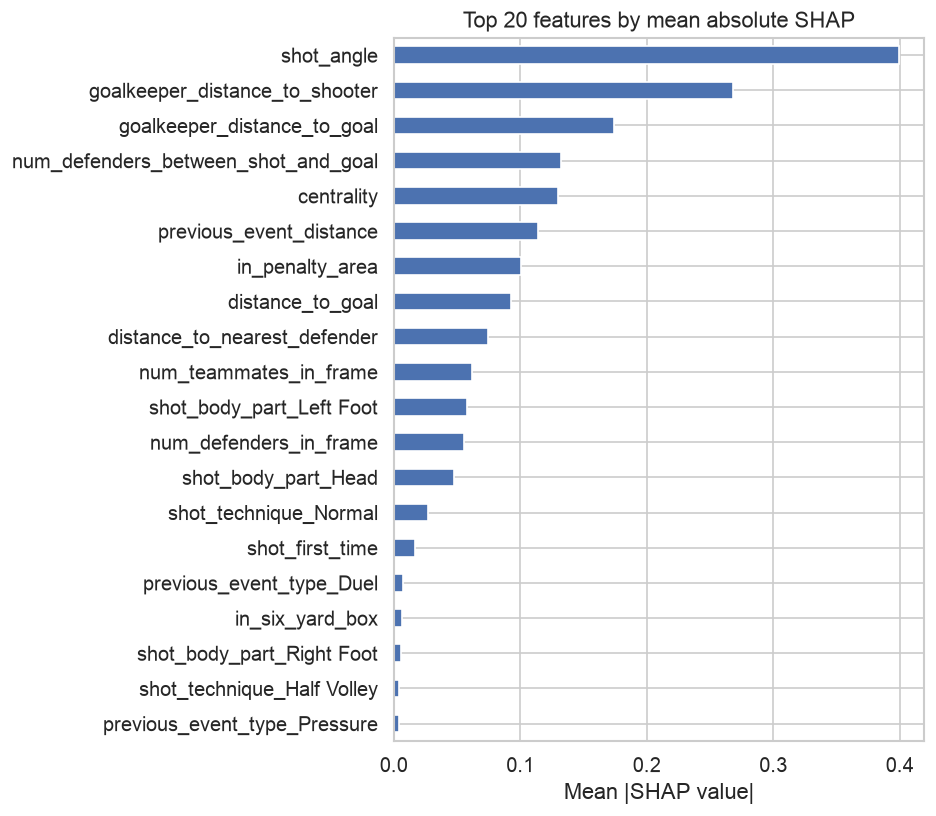

In [13]:
# Mean absolute SHAP — overall feature importance
mean_abs_shap = pd.Series(
    np.abs(shap_values).mean(axis=0),
    index=ALL_FEATURE_NAMES,
).sort_values(ascending=True)

top_n = 20
fig, ax = plt.subplots(figsize=(8, 7))
mean_abs_shap.tail(top_n).plot.barh(ax=ax, color='#4C72B0', edgecolor='white')
ax.set_xlabel('Mean |SHAP value|')
ax.set_title(f'Top {top_n} features by mean absolute SHAP')
plt.tight_layout()
plt.show()

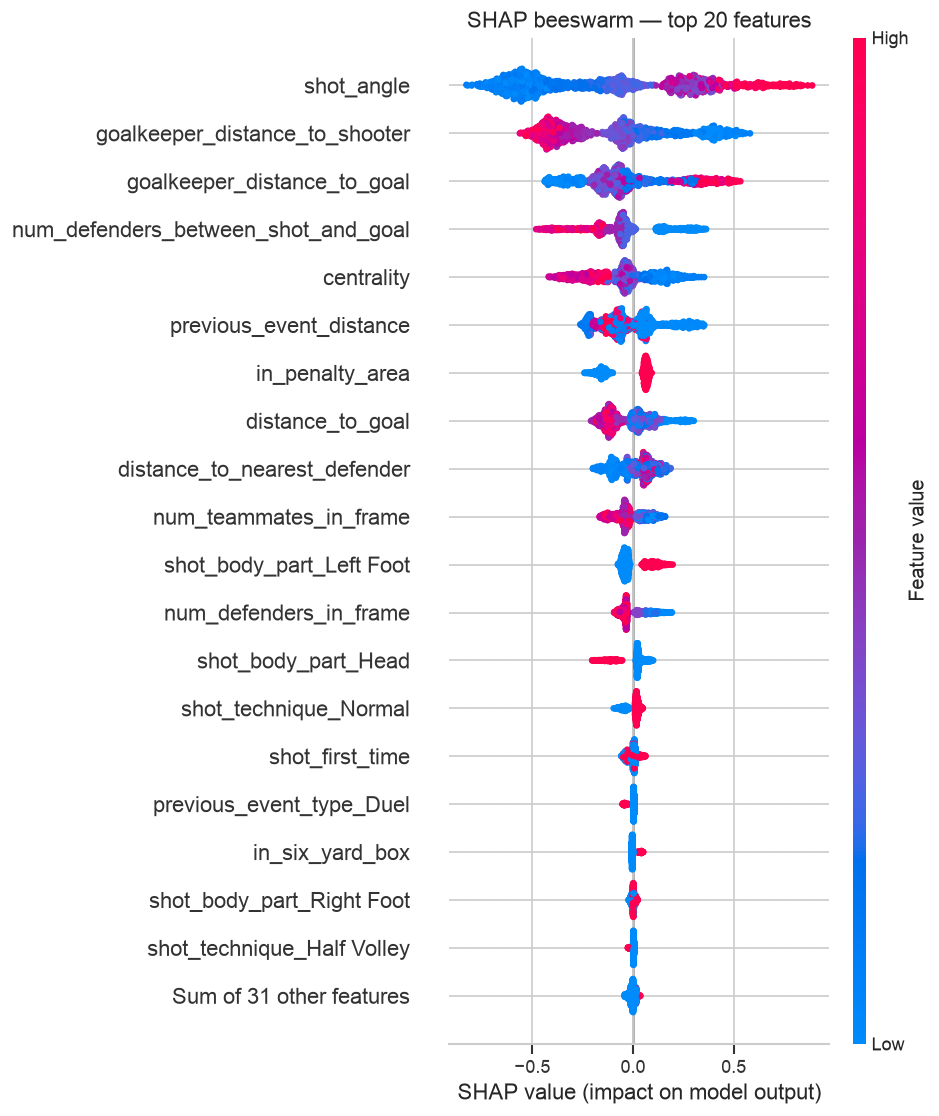

In [14]:
# Beeswarm plot — direction and magnitude of feature effects
shap_explanation = shap.Explanation(
    values=shap_values,
    base_values=explainer.expected_value,
    data=X_processed_df.values,
    feature_names=ALL_FEATURE_NAMES,
)
plt.figure(figsize=(10, 8))
shap.plots.beeswarm(shap_explanation, max_display=20, show=False)
plt.title('SHAP beeswarm — top 20 features')
plt.tight_layout()
plt.show()

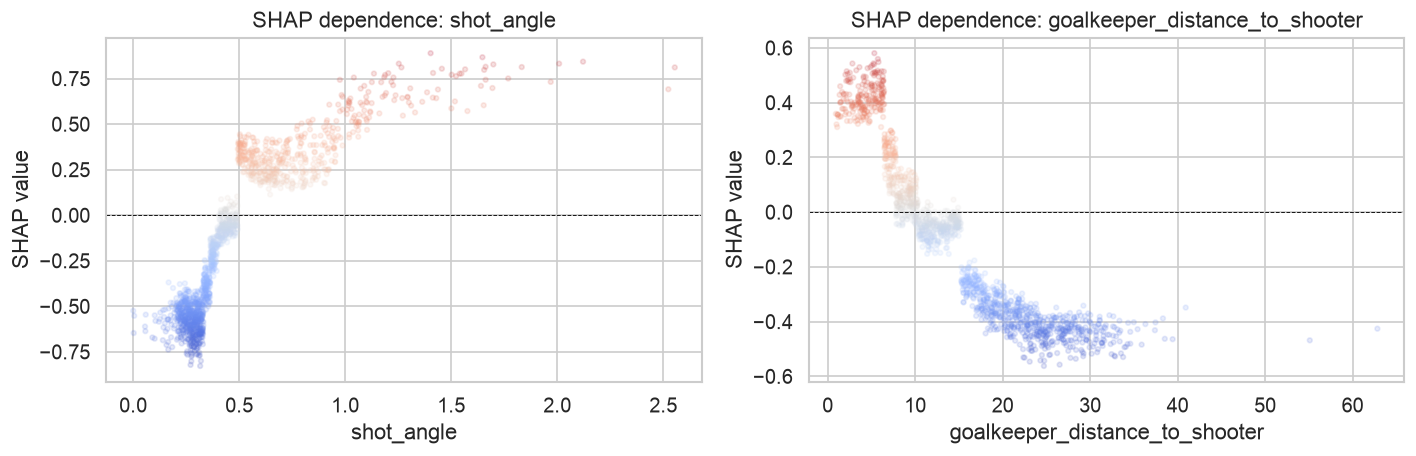

In [15]:
# Dependence plots for the two most important features
top2 = mean_abs_shap.tail(2).index.tolist()[::-1]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, feat in zip(axes, top2):
    feat_idx = ALL_FEATURE_NAMES.index(feat)
    ax.scatter(
        X_processed_df[feat], shap_values[:, feat_idx],
        alpha=0.15, s=8, c=shap_values[:, feat_idx], cmap='coolwarm',
    )
    ax.axhline(0, color='k', linewidth=0.6, linestyle='--')
    ax.set_xlabel(feat)
    ax.set_ylabel('SHAP value')
    ax.set_title(f'SHAP dependence: {feat}')
plt.tight_layout()
plt.show()

## 8. Results Summary

In [16]:
print("="*45)
print(" XGBoost xG Model — Final Results")
print("="*45)
print(f" Dataset:       {len(shots):,} open-play shots")
print(f" Goal rate:     {y.mean():.1%}")
print(f" Features:      {len(ALL_FEATURE_NAMES)} (after encoding)")
print(f" CV folds:      5-fold stratified")
print("-"*45)
for name, val in metrics.items():
    print(f" {name:<15} {val:.4f}")
print(f" ECE            {ece:.4f}")
print("-"*45)
print(f" Top feature:   {mean_abs_shap.index[-1]}")
print(f" Model saved:   {model_path}")
print("="*45)

 XGBoost xG Model — Final Results
 Dataset:       1,459 open-play shots
 Goal rate:     10.5%
 Features:      50 (after encoding)
 CV folds:      5-fold stratified
---------------------------------------------
 ROC-AUC         0.7959
 Log-loss        0.2759
 Brier score     0.0796
 ECE            0.0120
---------------------------------------------
 Top feature:   shot_angle


NameError: name 'model_path' is not defined